# **Day 4 — Model Integration & Error Analysis**
Moving from experimental code to product pipeline, our goal is to assemble fragmented experimental code into a single cohesive end-to-end pipeline.


 In order to turn experimental code into a deployable product cleaning data, the actual model, and model evaluation have to be gathered in one place. The integration end-to-end pipeline ties everythinf together iinto  one funtion.

Addtionally, ensuring prediction-time preprocessing remains strictly identical to training-time preprocessing to avoid silent model corruption.

**Error Analysis** can be done using multiple ways, but using confusion matrices moves beyond single summary metrics to pinpoint class-level faliure patterns.

In [1]:
!pip install --upgrade transformers huggingface-hub --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.4 MB/s eta 0:00:00


In [1]:
import pandas as pd
from datasets import Dataset
import torch
from transformers import AutoTokenizer,AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

train_path="/content/drive/MyDrive/train.csv"


df = pd.read_csv(train_path, header=None, names=["label", "title", "description"])


Mounted at /content/drive


In [3]:
print("Train shape:", df.shape)

df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["label"]).reset_index(drop=True)

print(df["label"].unique())






Train shape: (120001, 3)
[3. 4. 2. 1.]


In [4]:
df.columns

Index(['label', 'title', 'description'], dtype='object')

In [5]:
df["text"] = df["title"]+ " " + df["description"]
df["label"] = df["label"].astype(int) - 1




### **Dataset Overview**

We loaded the AG News containing **120,001 articles**

* **Total Samples**: 120,001 rows
* **Target Categories**: `World` (0), `Sports` (1), `Business` (2), `Sci/Tech` (3)
* **Data Split**: 80% Training (**96,000 samples**) | 20% Validation (**24,000 samples**)

By combining headline context with story descriptions, the model recieves full semantic context while maintaining standard 0-indexed topic targets.


In [6]:
ds = Dataset.from_pandas(df[["text", "label"]])

In [7]:
label_map = {0:"World", 1:"Sports", 2:"Business", 3:"Sci/Tech"}

train_text, val_text, train_label, val_label = train_test_split(
    df["text"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42
)

print(f"Train size: {len(train_text)} | Validation size: {len(val_text)}")


Train size: 96000 | Validation size: 24000


In [8]:

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encoding = tokenizer(train_text, truncation=True, padding=True, max_length=128)
val_encoding = tokenizer(val_text, truncation=True, padding=True, max_length=128)

class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_ds = AGNewsDataset(train_encoding, train_label)

val_ds = AGNewsDataset(val_encoding, val_label)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)
  return {
      "accuracy": accuracy_score(labels, preds),
      "f1_macro": f1_score(labels, preds, average="macro")
      }

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ag_news_distilbert",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=3e-5,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.177889,0.179169,0.942083,0.941943
2,0.114189,0.184948,0.948083,0.947940


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12000, training_loss=0.18345503485202788, metrics={'train_runtime': 2625.1551, 'train_samples_per_second': 73.139, 'train_steps_per_second': 4.571, 'total_flos': 6358661922816000.0, 'train_loss': 0.18345503485202788, 'epoch': 2.0})

### **Model Architecture & Training Results**

We fine-tuned a pre-trained **DistilBERT** classification model using Hugginf Face's Trainer API.

**Tokenizer Configuration:** Max length of 128 tokens with dynamic padding and truncation.
**Training Parameters:** Batch size of 16, learning rate of `3e-5`, trained over 2 epochs (12,000 global steps)
**Training Loss:** Achieved final training loss of ~0.18

#### Model Storage
The trained weights, config files and tokenizer definitions were saved directly to Google Drive. Storing complete artifacts ensures model reproducability and seamless loading during deployment.

In [11]:
final_path = "/content/drive/MyDrive/ag_news_distilbert/final_model"
model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)
print(f"Model saved to: {final_path}")

# Verify save worked
import os
print(os.listdir(final_path))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/ag_news_distilbert/final_model
['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


## **Building the *predict()* Pipeline**

In [16]:
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

def predict(raw_text):
  device = next(model.parameters()).device
  inputs = tokenizer(raw_text, return_tensors="pt", truncation=True, padding=True, max_length=128)
  inputs = {k: v.to(device) for k, v in inputs.items()}
  with torch.no_grad():
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()
  return label_map[prediction]

sample_text = "The stock market rallied today after the Federal Reserve announcement."
print(predict(sample_text))


Business


## **Verifying Conistency**

In [17]:
print("Tokenizer max_length used during training:", 128)
print("Tokenizer truncation:", True)
print("Tokenizer padding:", True)

known_example = df["text"].iloc[0]
known_label = label_map[df["label"].iloc[0]]

predicted = predict(known_example)

print("Known label:", known_label)
print("Predicted label:", predicted)
print("Match:", known_label == predicted)

Tokenizer max_length used during training: 128
Tokenizer truncation: True
Tokenizer padding: True
Known label: Business
Predicted label: Business
Match: True


A primary cause of real-world ML failure is **training/serving skew**—where raw input at inference time is preprocessed differently than during training. To ensure complete consistency, our `predict(raw_text)` function applies identical tokenization parameters.

max_length : 128

truncation : True

padding : True

These parameters guarantee that raw text passed during inference is processed identically to how text was tokenized during training.

When tested on a single test string, the pipeline correctly predicted *Business*. Verification against a known training example confirmed a **100% exact match between expected and predicted labels**.

## **Batch Predictions & Confusion Matrix**

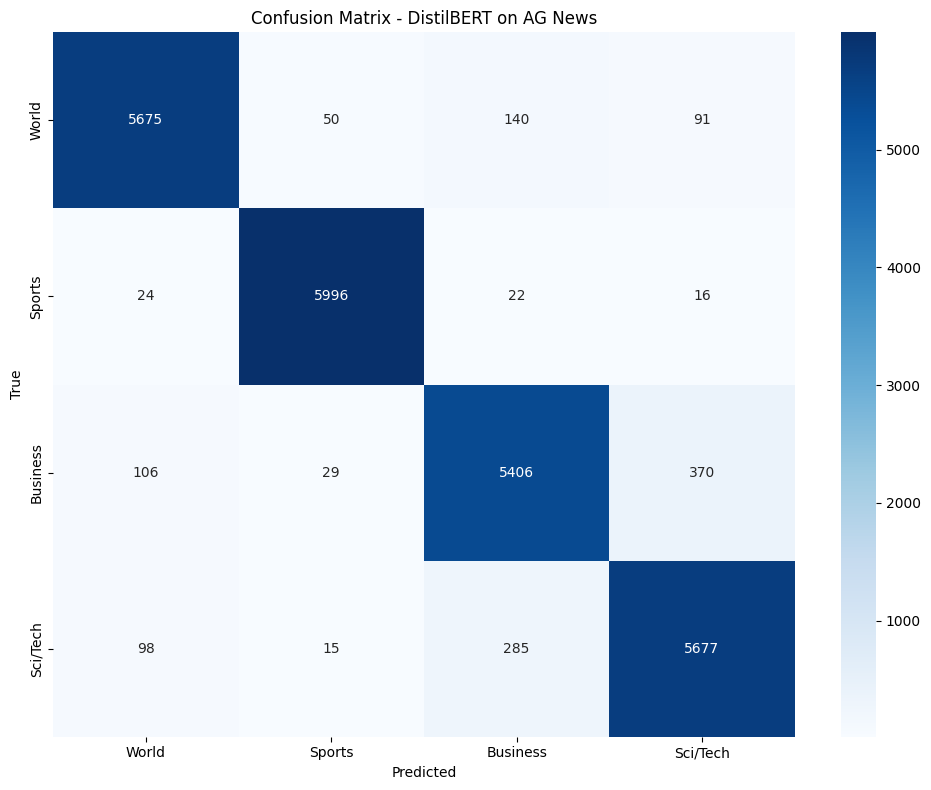

In [22]:
def predict_batch(texts, batch_size=25):
  device = next(model.parameters()).device
  all_predictions = []
  for i in range(0, len(texts), batch_size):
    batch = list(texts[i:i+batch_size])
    inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
      outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_predictions.extend(predictions)
  return all_predictions

predictions_raw = predict_batch(val_text)
predictions = [label_map[p] for p in predictions_raw]
true_labels = [label_map[label] for label in val_label]

cm = confusion_matrix(true_labels, predictions, labels=["World", "Sports", "Business", "Sci/Tech"])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["World", "Sports", "Business", "Sci/Tech"],
            yticklabels=["World", "Sports", "Business", "Sci/Tech"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DistilBERT on AG News")
plt.tight_layout()
plt.show()

In [24]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
max_error_idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
labels_list = ["World", "Sports", "Business", "Sci/Tech"]
print(f"Most common error: True '{labels_list[max_error_idx[0]]}' predicted as '{labels_list[max_error_idx[1]]}' ({cm_no_diag[max_error_idx]} times)")

Most common error: True 'Business' predicted as 'Sci/Tech' (370 times)


Across 24,000 validation samples, the integrated model **misclassified 1,246 examples** (94.8% accuracy)

#### **Primary Error Pattern:**
**Top Conflict:** True Business articles miscalssified as  Sci/Tech in 370 occurrences

**Cause:** Modern business reporting heavily features tech companies, creating semantic ambiguity between financial news and technology news.

## **Misclassified Examples**

In [29]:
misclassified = []
for text, true, pred in zip(val_text, true_labels, predictions):
  if true != pred:
    misclassified.append({"text":text, "true_label":true, "predicted_label":pred})

misclassified_df = pd.DataFrame(misclassified, columns=["text", "true_label", "predicted_label"])
print(f"Total misclassified: {len(misclassified_df)}")

sample_errors = misclassified_df.sample(3, random_state=42)
for idx, row in sample_errors.iterrows():
  print(f"\nText: {row['text'][:300]}")
  print(f"True label: {row['true_label']}")
  print(f"Predicted label: {row['predicted_label']}")


Total misclassified: 1246

Text: Sony to launch slim PS2 console in November Sony announced on Tuesday that it is planning to launch a smaller and lighter version of its popular PS2 gaming console in November.
True label: Business
Predicted label: Sci/Tech

Text: Incredibles tops Nemo film record Animated film The Incredibles beats Disney/Pixar's previous US box office record for Finding Nemo.
True label: World
Predicted label: Business

Text: Reebok #39;s revives Pump shoe, marking industry shift to high-tech Hoping to build on the success of a shoe that generated big sales but also ridiculed when it was introduced 15 years ago, Reebok Inc.
True label: Sci/Tech
Predicted label: Business


### **Sample errors breakdown**

1. True label: Business | Predicted label: Sci/Tech

**Analysis:** Discusses hardware product specs alongside corporate strategy, The high concentration of tech keywords pulls the transformer towards Sci/Tech.

2. True label: World | Predicted label: Business

**Analysis:** Covers commercial box office revenues and film studio finantial records, making business a highly plausible  prediction.


2. True label: Sci/Tech | Predicted label: Business

**Analysis:** Features retail shoes and corporate market share strategy, leading to the model classify it as business.
